# YOLO-Seg para segmentación de grietas

Entrenamos YOLO11-seg sobre DeepCrack para segmentar grietas y comparamos por IoU de segmentación semántica (píxel a píxel) contra otros dos modelos del grupo. Todos comparten la misma config de entrenamiento y las mismas etiquetas, y evalúan sobre el mismo test.

Modelos entrenados:

| # | Modelo | Qué cambia respecto del nano base |
|---|---|---|
| 1 | `nano` | — (referencia) |
| 2 | `small` | yolo11s en vez de nano |
| 3 | `nano_dilated1` | máscara de train dilatada 1px |
| 4* | `nano_hires` | imgsz=768 en vez de 512 (batch=4 por VRAM) |

\* `nano_hires` entrena a otra resolución, así que no comparte la config común y queda fuera de la comparación estricta; se reporta aparte como mejora en la sección 5.

Sobre estos modelos se barre el umbral de confianza (`conf`) y nos quedamos con el de mejor IoU semántico.

YOLO-Seg es segmentación de instancias por polígonos, no semántica nativa. La conversión máscara→polígono impone un techo de IoU; la sección 6 lo mide y explica por qué la conversión se hace sin simplificar los contornos.

In [1]:
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import Image, display
from ultralytics import YOLO

RUN_TRAINING = False  # True = reentrenar todo desde cero; False = usar best.pt en disco

print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA disponible: True
GPU: NVIDIA GeForce GTX 1650


In [2]:
# --- Config de entrenamiento COMÚN ---
BASE_CFG = dict(
    imgsz=512,        # resolución de trabajo (imágenes nativas: 544×384)
    batch=8,          # límite cómodo de VRAM (4 GB)
    scale=0.5,        # escala aleatoria en [1-s, 1+s]
    fliplr=0.5,       # flip horizontal
    degrees=0.0, flipud=0.0,             # sin rotación ni flip vertical
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,     # sin jitter de color
    mixup=0.0, copy_paste=0.0,           # sin mixup/copy_paste
    epochs=200, patience=30, seed=42,
)
IMGSZ = BASE_CFG["imgsz"]  # usado también en evaluación (debe coincidir con train)
print("Config de train común:")
for k, v in BASE_CFG.items():
    print(f"  {k} = {v}")

Config de train común:
  imgsz = 512
  batch = 8
  scale = 0.5
  fliplr = 0.5
  degrees = 0.0
  flipud = 0.0
  hsv_h = 0.0
  hsv_s = 0.0
  hsv_v = 0.0
  mixup = 0.0
  copy_paste = 0.0
  epochs = 200
  patience = 30
  seed = 42


In [3]:
# --- Rutas fijas ---
RUNS_DIR = Path.cwd() / "runs"
SEG_DIR = RUNS_DIR / "yolo_seg"
DATASETS = Path.cwd().parent.parent / "datasets"

# Dataset en formato YOLO-Seg (polígonos completos, sin simplificar). Se genera abajo si no existe.
DATA_YAML = DATASETS / "dataset_1000_yoloseg_fullpoly" / "data.yaml"
DATA_YAML_DILATED1 = DATASETS / "dataset_1000_yoloseg_dilated1" / "data.yaml"

TEST_IMAGES_DIR = DATA_YAML.parent / "test" / "images"
DEEPCRACK_TEST_LAB = DATASETS / "dataset_1000" / "test_lab"   # ground truth semántico real
test_files = sorted(TEST_IMAGES_DIR.glob("*.jpg"))

import prepare_data
if not DATA_YAML.exists():
    prepare_data.build_dataset(force=True, out_root=DATA_YAML.parent)          # polígonos completos
if not DATA_YAML_DILATED1.exists():
    prepare_data.build_dataset(force=True, dilate_train_px=1, out_root=DATA_YAML_DILATED1.parent)

print("data.yaml (polígonos completos):", DATA_YAML.exists())
print("data.yaml (dilated1):", DATA_YAML_DILATED1.exists())
print("test:", TEST_IMAGES_DIR.exists(), f"({len(test_files)} imgs)")

data.yaml (polígonos completos): True
data.yaml (dilated1): True
test: True (237 imgs)


In [4]:
# --- Utilidades de evaluación semántica (usadas por todos los modelos) ---

def semantic_iou(pred_mask, gt_mask):
    """IoU a nivel píxel entre dos máscaras binarias. NaN si ambas vacías."""
    pred_mask, gt_mask = np.squeeze(pred_mask), np.squeeze(gt_mask)
    inter = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()
    return float("nan") if union == 0 else inter / union


def predict_semantic_mask(model, img_path, conf=0.10, imgsz=IMGSZ):
    """Inferencia YOLO-Seg -> une todas las máscaras de instancia en una binaria (H, W)."""
    result = model.predict(str(img_path), conf=conf, imgsz=imgsz, verbose=False)[0]
    h, w = result.orig_shape
    semantic = np.zeros((h, w), dtype=bool)
    if result.masks is not None:
        for m in result.masks.data.cpu().numpy():
            m_resized = cv2.resize(np.squeeze(m), (w, h), interpolation=cv2.INTER_NEAREST)
            semantic |= m_resized > 0.5
    return semantic


def evaluate_semantic_iou(model, conf=0.10, imgsz=IMGSZ):
    """IoU semántico sobre todo el test. Devuelve mean/median + IoU por imagen."""
    per_image = []
    for img_path in test_files:
        gt = cv2.imread(str(DEEPCRACK_TEST_LAB / f"{img_path.stem}.png"), cv2.IMREAD_GRAYSCALE)
        gt_mask = np.squeeze(gt) > 127
        pred = predict_semantic_mask(model, img_path, conf=conf, imgsz=imgsz)
        per_image.append((img_path, semantic_iou(pred, gt_mask)))
    ious = np.array([i for _, i in per_image]); valid = ~np.isnan(ious)
    return {"mean": float(ious[valid].mean()), "median": float(np.median(ious[valid])),
            "per_image": per_image}


def plot_training_curves(run_name, title):
    df = pd.read_csv(SEG_DIR / run_name / "results.csv"); df.columns = df.columns.str.strip()
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].plot(df["epoch"], df["train/seg_loss"], label="train"); ax[0].plot(df["epoch"], df["val/seg_loss"], label="val")
    ax[0].set_title(f"Seg loss — {title}"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(df["epoch"], df["metrics/mAP50(M)"], label="mAP50"); ax[1].plot(df["epoch"], df["metrics/mAP50-95(M)"], label="mAP50-95")
    ax[1].set_title(f"mAP máscara — {title}"); ax[1].set_xlabel("epoch"); ax[1].legend()
    ax[2].plot(df["epoch"], df["metrics/precision(M)"], label="precision"); ax[2].plot(df["epoch"], df["metrics/recall(M)"], label="recall")
    ax[2].set_title(f"Precision/Recall — {title}"); ax[2].set_xlabel("epoch"); ax[2].legend()
    plt.tight_layout(); out = SEG_DIR / run_name / "training_curves.png"; fig.savefig(out, dpi=100); plt.close(fig)
    return Image(str(out))


def train_and_eval(run_name, pretrained, data_yaml, title, extra_cfg=None):
    """Entrena (si RUN_TRAINING) con BASE_CFG (+ extra_cfg), evalúa instancia y semántica,
    registra la fila en results_registry. Devuelve el modelo best."""
    if RUN_TRAINING:
        cfg = {**BASE_CFG, **(extra_cfg or {})}
        YOLO(pretrained).train(data=str(data_yaml), project=str(SEG_DIR), name=run_name, **cfg)
    best = SEG_DIR / run_name / "weights" / "best.pt"
    if not best.exists():
        print(f"[{run_name}] sin weights todavía — corré con RUN_TRAINING=True.")
        return None
    model = YOLO(str(best))
    m = model.val(data=str(DATA_YAML), split="test", imgsz=IMGSZ,
                    project=str(SEG_DIR), name=f"{run_name}_test_eval", exist_ok=True)
    iou = evaluate_semantic_iou(model)
    results_registry[title] = {"mAP50_mask": round(m.seg.map50, 4),
                                "mAP50_95_mask": round(m.seg.map, 4),
                                "iou_semantico": round(iou["mean"], 4)}
    print(f"[{title}] mAP50(M)={m.seg.map50:.3f}  mAP50-95(M)={m.seg.map:.3f}  "
            f"IoU semántico={iou['mean']:.4f}")
    return model


results_registry = {}

## 2. Modelo 1 — `nano` (referencia)

`yolo11n-seg` con la config común y las etiquetas en formato YOLO-Seg. Es el modelo base
contra el que se miden los otros.

In [5]:
model_nano = train_and_eval("yolo11n_seg_nano", "yolo11n-seg.pt", DATA_YAML, "nano")

Ultralytics 8.4.102  Python-3.12.12 torch-2.13.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
WARNING val: Slow image access detected (ping: 0.40.0 ms, read: 15.15.4 MB/s, size: 159.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning D:\ESTUDIOS\posgrado\Materias\CEIA (4) Vision por computadora II\tp_computer_vision_ii\datasets\dataset_1000_yoloseg_fullpoly\test\labels.cache... 237 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 237/237  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.9it/s 5.2s0.2s
                   all        237        951      0.485       0.34      0.296      0.163      0.478       0.32      0.275     0.0964
Speed: 2.8ms preprocess, 5.8ms inference, 0.0

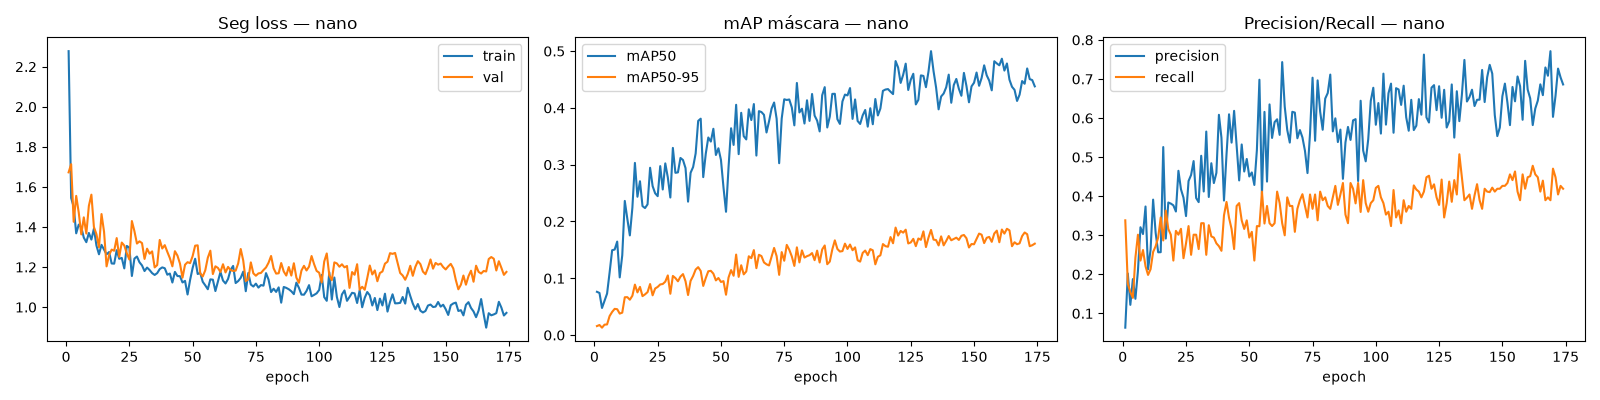

In [6]:
if model_nano is not None:
    display(plot_training_curves("yolo11n_seg_nano", "nano"))

## 3. Modelo 2 — `small` (yolo11s)

Igual que el nano en todo salvo el tamaño de red: `yolo11s-seg` (~10M params contra ~2.8M del nano). Sirve para ver si la red más grande justifica su costo en un dataset chico como este.

In [7]:
model_small = train_and_eval("yolo11s_seg_small", "yolo11s-seg.pt", DATA_YAML, "small")

Ultralytics 8.4.102  Python-3.12.12 torch-2.13.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
YOLO11s-seg summary (fused): 114 layers, 10,067,203 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 625.8226.6 MB/s, size: 184.9 KB)
val: Scanning D:\ESTUDIOS\posgrado\Materias\CEIA (4) Vision por computadora II\tp_computer_vision_ii\datasets\dataset_1000_yoloseg_fullpoly\test\labels.cache... 237 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 237/237  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.8it/s 5.3s0.3s
                   all        237        951       0.55      0.323      0.316      0.186      0.503      0.324      0.292      0.106
Speed: 1.1ms preprocess, 9.6ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to D:\ESTUDIOS\posgrado\Materias\CEIA (4) Vision por computadora II\tp_computer_vision_ii\src\yolo

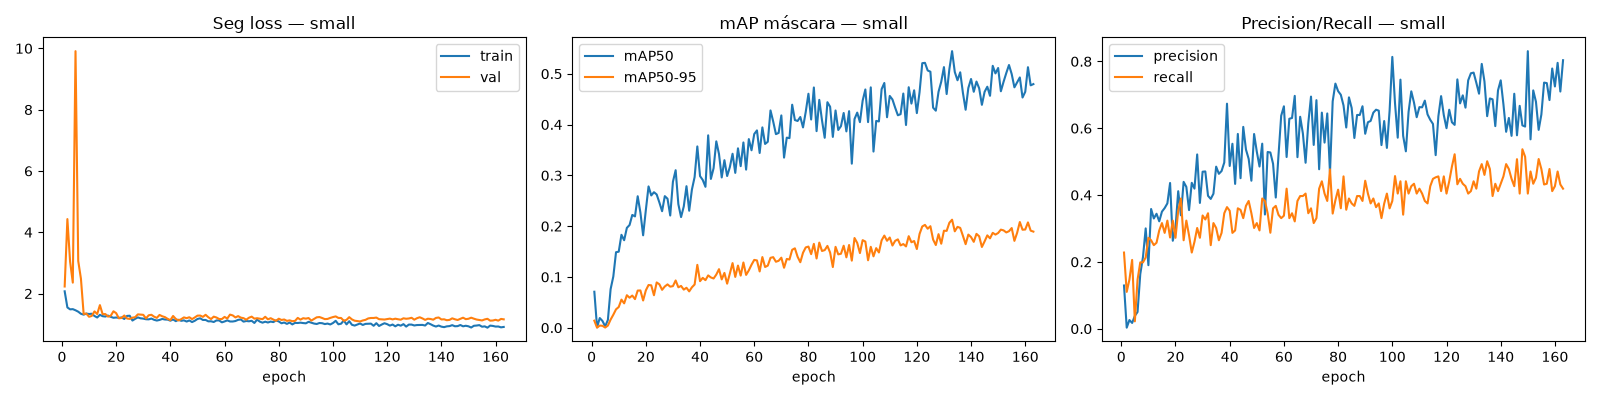

In [8]:
if model_small is not None:
    display(plot_training_curves("yolo11s_seg_small", "small"))

## 4. Modelo 3 — `nano_dilated1` (train con máscara dilatada 1px)

Nano con la config común, pero entrenado sobre el dataset con la máscara de train dilatada 1 px (`dataset_1000_yoloseg_dilated1/`). Val y test se siguen midiendo contra el ground truth sin dilatar. La idea es que un contorno de train un poco más grueso dé predicciones que calcen mejor con el grosor real de la grieta.

In [9]:
model_dilated1 = train_and_eval("yolo11n_seg_dilated1", "yolo11n-seg.pt",
                                DATA_YAML_DILATED1, "nano_dilated1")

Ultralytics 8.4.102  Python-3.12.12 torch-2.13.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 733.0290.2 MB/s, size: 185.4 KB)
val: Scanning D:\ESTUDIOS\posgrado\Materias\CEIA (4) Vision por computadora II\tp_computer_vision_ii\datasets\dataset_1000_yoloseg_fullpoly\test\labels.cache... 237 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 237/237  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 3.5it/s 4.3s0.2s
                   all        237        951      0.468      0.323      0.296      0.171      0.444      0.292      0.249     0.0824
Speed: 1.1ms preprocess, 3.9ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to D:\ESTUDIOS\posgrado\Materias\CEIA (4) Vision por computadora II\tp_computer_vision_ii\src\yolo_s

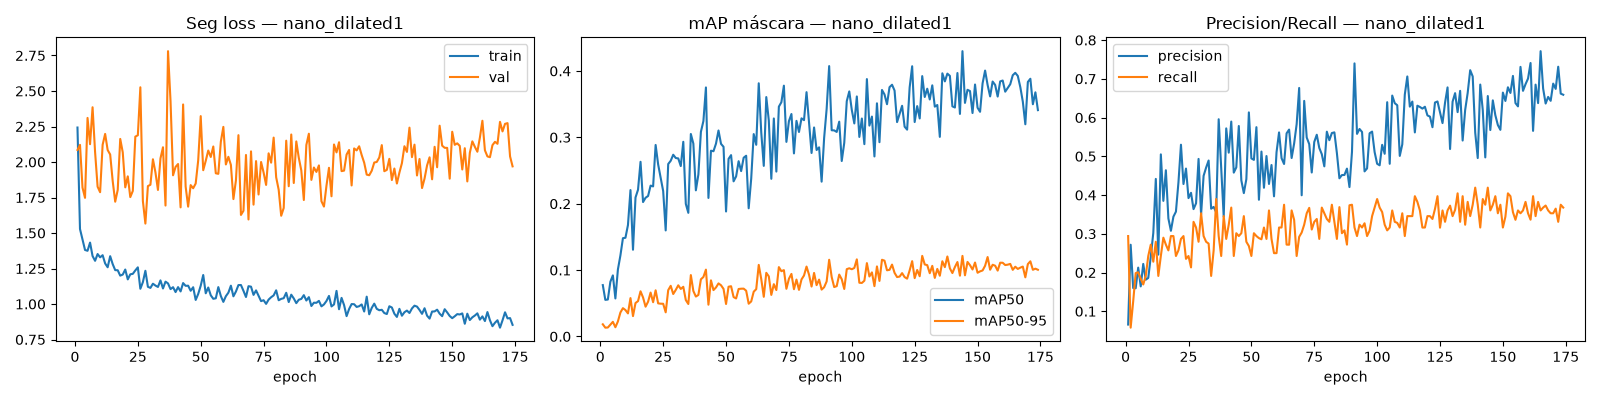

In [10]:
if model_dilated1 is not None:
    display(plot_training_curves("yolo11n_seg_dilated1", "nano_dilated1"))

## 5. Modelo de mejora

Los modelos anteriores usan imgsz=512 para ser comparables entre sí y con el resto del grupo. Pero las imágenes de DeepCrack son 544×384, así que 512 queda por debajo de la resolución nativa en el lado largo, y las grietas —de pocos píxeles de ancho— son muy sensibles a eso. Este modelo entrena a imgsz=768 con el resto de la config igual, para ver cuánto rinde YOLO-Seg con más resolución. Baja a batch=4 por la VRAM; es el único cambio y viene forzado por el hardware.

In [11]:
# Modelo de MEJORA: nano a alta resolución (768).
mejora_registry = {}
MEJORA_IMGSZ = 768

if RUN_TRAINING:
    cfg_hires = {**BASE_CFG, "imgsz": MEJORA_IMGSZ, "batch": 4}
    YOLO("yolo11n-seg.pt").train(data=str(DATA_YAML), project=str(SEG_DIR),
                                 name="yolo11n_seg_hires", **cfg_hires)

best_hires = SEG_DIR / "yolo11n_seg_hires" / "weights" / "best.pt"
if best_hires.exists():
    model_hires = YOLO(str(best_hires))
    m_hi = model_hires.val(data=str(DATA_YAML), split="test", imgsz=MEJORA_IMGSZ,
                           project=str(SEG_DIR), name="yolo11n_seg_hires_test_eval", exist_ok=True)
    # barrido corto de conf a la resolución de mejora
    best_iou_hi, best_conf_hi = -1, 0.05
    for conf in [0.10, 0.05, 0.01]:
        iou_c = evaluate_semantic_iou(model_hires, conf=conf, imgsz=MEJORA_IMGSZ)["mean"]
        if iou_c > best_iou_hi:
            best_iou_hi, best_conf_hi = iou_c, conf
    mejora_registry["nano_hires (imgsz=768)"] = {
        "mAP50_mask": round(m_hi.seg.map50, 4), "mAP50_95_mask": round(m_hi.seg.map, 4),
        "iou_semantico": round(best_iou_hi, 4), "conf": best_conf_hi, "imgsz": MEJORA_IMGSZ,
    }
    print(f"[nano_hires @768] IoU semántico={best_iou_hi:.4f} (conf={best_conf_hi})  "
          f"mAP50(M)={m_hi.seg.map50:.3f}")
    print(f"Comparar contra el mejor a 512 (comparación estricta): "
          f"{max(results_registry.values(), key=lambda v: v['iou_semantico'])['iou_semantico'] if results_registry else 'n/a'}")
else:
    model_hires = None
    print("[nano_hires] sin weights todavía — corré con RUN_TRAINING=True.")

Ultralytics 8.4.102  Python-3.12.12 torch-2.13.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 823.2280.6 MB/s, size: 203.6 KB)
val: Scanning D:\ESTUDIOS\posgrado\Materias\CEIA (4) Vision por computadora II\tp_computer_vision_ii\datasets\dataset_1000_yoloseg_fullpoly\test\labels.cache... 237 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 237/237  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.5it/s 6.1s0.3s
                   all        237        951       0.44      0.339      0.299      0.154      0.427      0.325      0.266     0.0937
Speed: 3.1ms preprocess, 9.0ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to D:\ESTUDIOS\posgrado\Materias\CEIA (4) Vision por computadora II\tp_computer_vision_ii\src\yolo_s

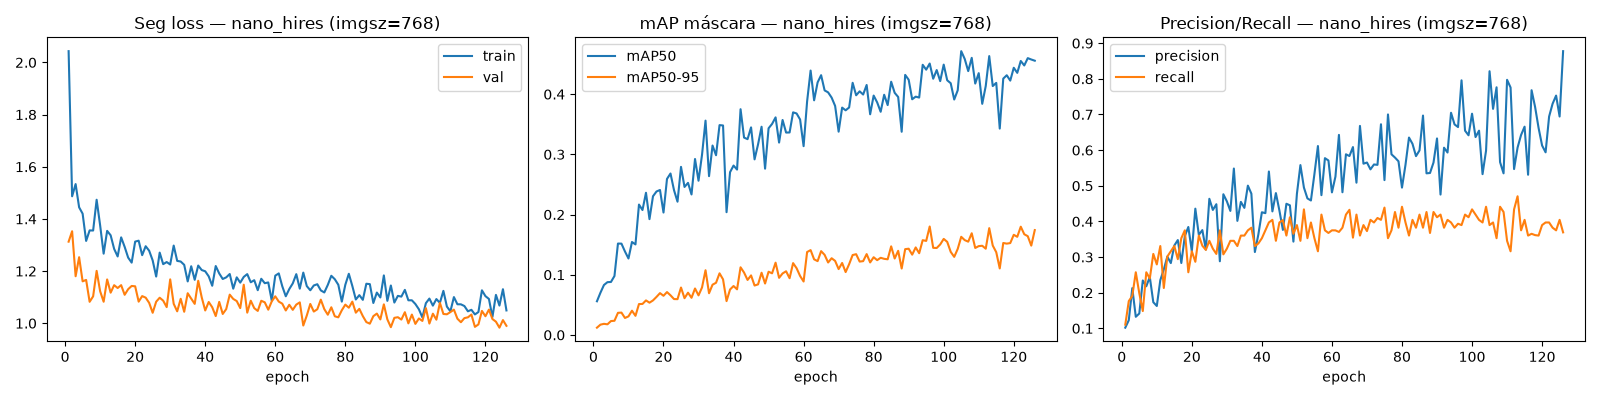

In [12]:
if model_hires is not None:
    display(plot_training_curves("yolo11n_seg_hires", "nano_hires (imgsz=768)"))

Subir la resolución de train de 512 a 768 recupera buena parte del IoU que la comparación a 512 dejaba sobre la mesa, y es lo que más movió la aguja para YOLO-Seg en grietas. Queda como mejora fuera de la comparación en igualdad de condiciones; si se quisiera subir la resolución de los tres modelos, va por acá.

## 6. El techo de la conversión máscara → polígono

YOLO-Seg entrena sobre polígonos, no píxeles, así que hay que convertir cada máscara de DeepCrack a contornos. Esa conversión puede perder área real de la grieta por dos lados:

1. Simplificar el contorno (`approxPolyDP`): en grietas de 2–3 px recorta los vértices que definen el grosor del trazo.
2. Quedarse con un solo contorno por componente: descarta ramas y lazos internos.

Por eso `mask_to_polygons` no simplifica (`simplify=False`) y conserva todos los contornos. La celda de abajo mide el impacto con el techo de IoU: el IoU que daría un modelo perfecto que reprodujera exactamente las labels. Se comparan las dos variantes de conversión para justificar la elegida.

In [13]:
import importlib
importlib.reload(prepare_data)
lab_files = sorted(DEEPCRACK_TEST_LAB.glob("*.png"))

def _rasterize(polys, h, w):
    canvas = np.zeros((h, w), np.uint8)
    for p in polys:
        cv2.fillPoly(canvas, [p.astype(np.int32)], 1)
    return canvas > 0

def ceiling_iou(simplify):
    ious = []
    for f in lab_files:
        mask = np.squeeze(cv2.imread(str(f), cv2.IMREAD_GRAYSCALE))
        gt = mask > 127
        h, w = mask.shape[:2]
        recon = _rasterize(prepare_data.mask_to_polygons(mask, simplify=simplify), h, w)
        u = (gt | recon).sum()
        if u > 0:
            ious.append((gt & recon).sum() / u)
    return float(np.mean(ious))

techo_simpl = ceiling_iou(True)
techo_full = ceiling_iou(False)
print(f"Techo IoU — conversión simplificada (approxPolyDP):  {techo_simpl:.4f}")
print(f"Techo IoU — conversión completa (sin simplificar):   {techo_full:.4f}")
print(f"\nSimplificando, ningún modelo YOLO-Seg puede pasar de {techo_simpl:.2f} de IoU por más")
print("que entrene bien. Por eso la conversión no simplifica los contornos.")

Techo IoU — conversión simplificada (approxPolyDP):  0.8831
Techo IoU — conversión completa (sin simplificar):   0.9842

Simplificando, ningún modelo YOLO-Seg puede pasar de 0.88 de IoU por más
que entrene bien. Por eso la conversión no simplifica los contornos.


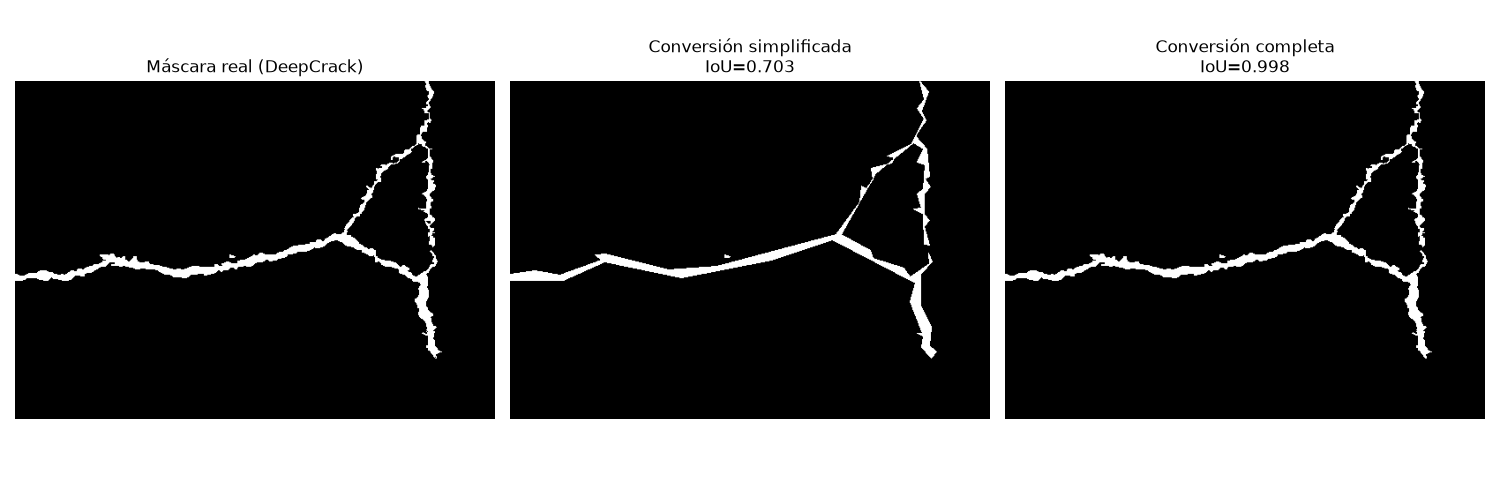

In [14]:
# Comparación visual: máscara real vs. conversión simplificada vs. conversión completa
FIGURES_DIR = Path.cwd() / "figures"; FIGURES_DIR.mkdir(exist_ok=True)
sample = "11129"
mask = np.squeeze(cv2.imread(str(DEEPCRACK_TEST_LAB / f"{sample}.png"), cv2.IMREAD_GRAYSCALE))
gt = mask > 127; h, w = mask.shape[:2]
recon_simpl = _rasterize(prepare_data.mask_to_polygons(mask, simplify=True), h, w)
recon_full = _rasterize(prepare_data.mask_to_polygons(mask, simplify=False), h, w)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(gt, cmap="gray");         ax[0].set_title("Máscara real (DeepCrack)")
ax[1].imshow(recon_simpl, cmap="gray"); ax[1].set_title(f"Conversión simplificada\nIoU={(gt&recon_simpl).sum()/(gt|recon_simpl).sum():.3f}")
ax[2].imshow(recon_full, cmap="gray");  ax[2].set_title(f"Conversión completa\nIoU={(gt&recon_full).sum()/(gt|recon_full).sum():.3f}")
for a in ax: a.axis("off")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "label_ceiling_comparison.png", dpi=100); plt.close(fig)
Image(str(FIGURES_DIR / "label_ceiling_comparison.png"))

Un modelo de segmentación semántica nativa no paga este costo porque predice la máscara de píxeles directamente, sin pasar por polígonos. Esa es la diferencia que el TP compara: no cuál es mejor, sino instancias por polígonos (YOLO) contra semántico, sobre el mismo test.

## 7. Barrido de confianza (`conf`)

Sobre el mejor modelo por IoU semántico se barre el umbral de confianza. Un `conf` bajo recupera grietas tenues (sube el recall) a costa de más falsos positivos; se elige el que maximiza el IoU semántico medio.

In [15]:
best_name = max(results_registry, key=lambda k: results_registry[k]["iou_semantico"]) if results_registry else None
best_models = {"nano": model_nano, "small": model_small,
               "nano_dilated1": model_dilated1}
best_model = best_models.get(best_name)

if best_model is not None:
    rows = []
    for conf in [0.25, 0.15, 0.10, 0.05, 0.01]:
        r = evaluate_semantic_iou(best_model, conf=conf)
        rows.append({"conf": conf, "iou_mean": round(r["mean"], 4), "iou_median": round(r["median"], 4)})
    conf_df = pd.DataFrame(rows)
    print(f"Barrido de conf sobre el mejor modelo: {best_name}")
    print(conf_df.to_string(index=False))
    best_conf = conf_df.loc[conf_df["iou_mean"].idxmax(), "conf"]
    print(f"\nMejor conf: {best_conf} (IoU mean = {conf_df['iou_mean'].max():.4f})")
else:
    print("Sin modelos entrenados — corré las secciones 2-5 con RUN_TRAINING=True.")
    best_conf = 0.10

Barrido de conf sobre el mejor modelo: nano_dilated1
 conf  iou_mean  iou_median
 0.25    0.4290      0.4370
 0.15    0.4335      0.4417
 0.10    0.4344      0.4419
 0.05    0.4345      0.4387
 0.01    0.4246      0.4262

Mejor conf: 0.05 (IoU mean = 0.4345)


## 8. Resumen y modelo final

Los modelos ordenados por IoU semántico, que es la métrica con la que se compara otros modelos. El de mejor IoU queda como modelo final.

In [16]:
# Comparación ESTRICTA (todos a imgsz=512, config común)
if results_registry:
    summary = pd.DataFrame(results_registry).T
    summary.index.name = "modelo"; summary = summary.reset_index()
    summary = summary.sort_values("iou_semantico", ascending=False)
    summary.to_csv(SEG_DIR / "comparison_final.csv", index=False)
    print("=== COMPARACIÓN ESTRICTA (imgsz=512, config común del grupo) ===")
    print(summary.to_string(index=False))

    final_name = summary.iloc[0]["modelo"]
    print(f"\n>>> MEJOR MODELO COMPARABLE: {final_name}  "
          f"(IoU semántico = {summary.iloc[0]['iou_semantico']})")
    print(">>> Este es el número que se compara con los otros modelos del grupo.")
else:
    print("Sin resultados — entrená los modelos con RUN_TRAINING=True.")

# Mejora documentada (fuera de la comparación estricta)
if 'mejora_registry' in dir() and mejora_registry:
    mejora = pd.DataFrame(mejora_registry).T.reset_index().rename(columns={"index": "modelo"})
    mejora.to_csv(SEG_DIR / "comparison_mejora.csv", index=False)
    print("\n=== MEJORA (imgsz=768, fuera de la comparación estricta, documentada aparte) ===")
    print(mejora.to_string(index=False))

=== COMPARACIÓN ESTRICTA (imgsz=512, config común del grupo) ===
       modelo  mAP50_mask  mAP50_95_mask  iou_semantico
nano_dilated1      0.2493         0.0824         0.4344
         nano      0.2755         0.0964         0.3989
        small      0.2924         0.1064         0.3989

>>> MEJOR MODELO COMPARABLE: nano_dilated1  (IoU semántico = 0.4344)
>>> Este es el número que se compara con los otros modelos del grupo.

=== MEJORA (imgsz=768, fuera de la comparación estricta, documentada aparte) ===
                modelo  mAP50_mask  mAP50_95_mask  iou_semantico  conf  imgsz
nano_hires (imgsz=768)      0.2656         0.0937         0.6798  0.05  768.0


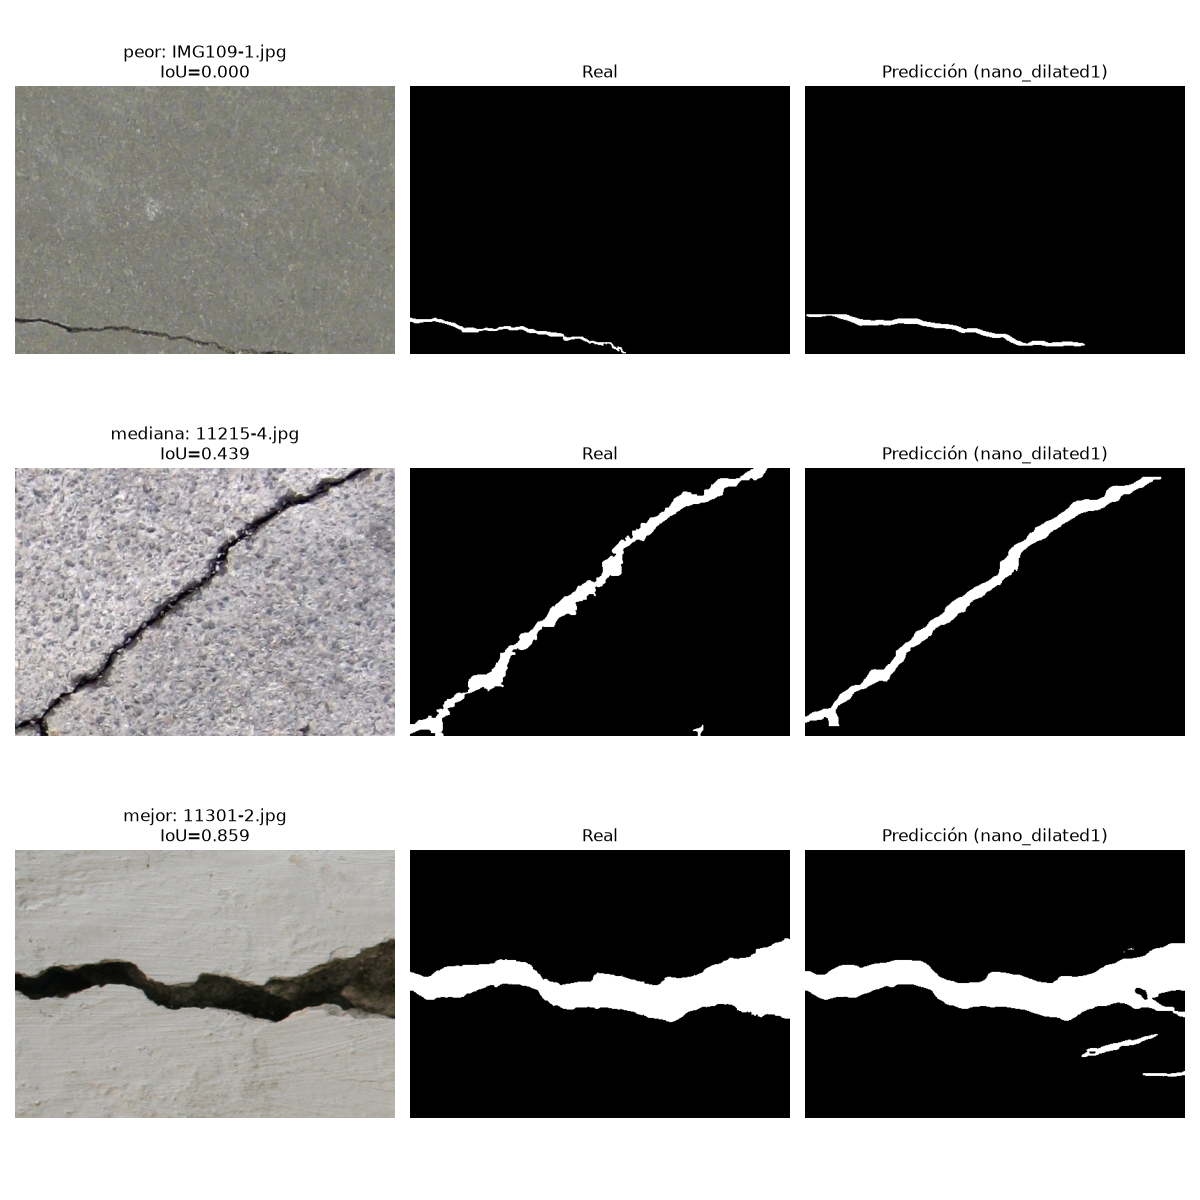

In [17]:
# Muestras representativas del modelo final (peor / mediana / mejor)
FIGURES_DIR = Path.cwd() / "figures"; FIGURES_DIR.mkdir(exist_ok=True)
final_model = best_models.get(best_name) if results_registry else None
if final_model is not None:
    r = evaluate_semantic_iou(final_model, conf=best_conf)
    per = sorted([(p, i) for p, i in r["per_image"] if not np.isnan(i)], key=lambda x: x[1])
    picks = [per[0], per[len(per)//2], per[-1]]; titles = ["peor", "mediana", "mejor"]
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for row, ((img_path, iou_val), t) in enumerate(zip(picks, titles)):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        gt = cv2.imread(str(DEEPCRACK_TEST_LAB / f"{img_path.stem}.png"), cv2.IMREAD_GRAYSCALE) > 127
        pred = predict_semantic_mask(final_model, img_path, conf=best_conf)
        axes[row, 0].imshow(img);              axes[row, 0].set_title(f"{t}: {img_path.name}\nIoU={iou_val:.3f}")
        axes[row, 1].imshow(gt, cmap="gray");  axes[row, 1].set_title("Real")
        axes[row, 2].imshow(pred, cmap="gray");axes[row, 2].set_title(f"Predicción ({best_name})")
        for a in axes[row]: a.axis("off")
    plt.tight_layout(); fig.savefig(FIGURES_DIR / "semantic_samples_final.png", dpi=100); plt.close(fig)
    display(Image(str(FIGURES_DIR / "semantic_samples_final.png")))

## Conclusión

Todos los modelos comparten la config de entrenamiento (imgsz=512, scale, fliplr, batch=8, sin rotación/color/mixup) y las mismas etiquetas, así que las diferencias entre ellos se deben solo a lo que cada uno cambia: tamaño de red o dilatación de train. El test es el mismo que usan los otros modelos del grupo, así que el `iou_semantico` de la tabla se compara directo con sus números.

Nos quedamos con el modelo de mejor IoU. Lo que más pesó no fue el augmentation sino la conversión máscara→polígono sin simplificar (ver el techo de IoU en la sección 6). Y la diferencia de fondo con un modelo semántico no es de ajuste, es de paradigma: instancias por polígonos contra segmentación de píxeles.

Nota sobre la evaluación: acá la inferencia reescala la máscara sin descontar el padding de letterbox, así que en algunas imágenes verticales la máscara queda corrida. Los números finales están en `03_eval.ipynb`, que re-evalúa estos mismos pesos con `retina_masks=True`.